In [5]:
!pip install pandas numpy matplotlib seaborn scikit-learn


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
 # Part A: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

# Part B: Load Dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

# Part C: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Part D: Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data Loaded, Split, and Scaled Successfully!")

Data Loaded, Split, and Scaled Successfully!


In [7]:
# Part E: Baseline Model (Logistic Regression)
print("--- Logistic Regression (Baseline) ---")
model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_train_scaled, y_train)
y_pred_lr = model_lr.predict(X_test_scaled)
print(classification_report(y_test, y_pred_lr))

# Part F: Random Forest Model
print("--- Random Forest Classifier ---")
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train) # Tree models don't strictly need scaled data
y_pred_rf = rf.predict(X_test)
print(classification_report(y_test, y_pred_rf))

# Part G: Gradient Boosting Model
print("--- Gradient Boosting Classifier ---")
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
print(classification_report(y_test, y_pred_gb))

--- Logistic Regression (Baseline) ---
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

--- Random Forest Classifier ---
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

--- Gradient Boosting Classifier ---
              precision    recall  f1-score   support

           0       0.97      0.90      0.94        42
           1       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       

--- GridSearchCV for Random Forest ---
Best Parameters: {'max_depth': 5, 'n_estimators': 100}


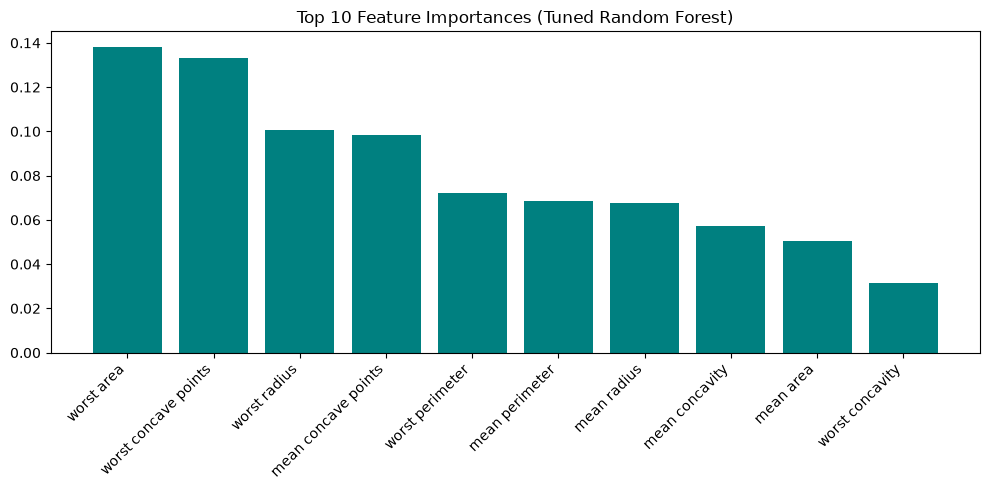

In [8]:
# Part H: Hyperparameter Tuning (GridSearchCV)
print("--- GridSearchCV for Random Forest ---")
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5, 7]
}

grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=3)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

best_rf = grid.best_estimator_
y_pred_tuned = best_rf.predict(X_test)

# Optional Advanced: Feature Importance Visualization
importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1][:10] # Top 10 features

plt.figure(figsize=(10, 5))
plt.title("Top 10 Feature Importances (Tuned Random Forest)")
plt.bar(range(10), importances[indices], align="center", color="teal")
plt.xticks(range(10), [data.feature_names[i] for i in indices], rotation=45, ha='right')
plt.tight_layout()
plt.show()